# Notebook 3 — Spatial objects and their parts
## Anatomy by composition: classifying Mary's breast from its parts

On 2026-07-01 Mary will undergo a **lumpectomy of the left breast**. Surgery is impossible to model without internal anatomy: we need to know that a breast is made of *something* — specifically, a small set of distinct kinds of tissue — before we can talk about excising a localised region.

Until now the `Breast` class has been a placeholder. NB2 used it merely as the type of the bearer of `breast_location_role_feb25` and `mary_left_breast` was an opaque individual. In this notebook we **open it up**: the breast acquires four anatomical sub-parts (the nipple, the mammary gland, the adipose tissue, the skin), declared mutually exclusive, and the `Breast` class is upgraded so that the reasoner can recognise breast-hood from composition.

The reasoner then does something important. Given Mary's *right* breast — a fresh individual we never type explicitly — and the four anatomical parts asserted on it, the reasoner will *infer* `Breast` membership from the parts alone. That is classification by composition, and it is one of the clearest payoffs of moving from a plain hierarchical taxonomy to an OWL-defined class.

## Learning objectives

1. Declare four anatomical sub-classes of `sulo:SpatialObject` — `Nipple`, `MammaryGland`, `AdiposeTissue`, `SkinOfBreast`
2. Assert `AllDisjoint` over these four classes, so that an instance of one cannot simultaneously be an instance of another
3. Define `Breast` using two complementary axioms — an *equivalent class* with existential restrictions (sufficient for classification under OWA) and *sub-class axioms* carrying cardinality and universal closure (necessary constraints on any individual classified as a `Breast`)
4. Open up `mary_left_breast` (introduced in NB2 as a role-bearer) by asserting its four anatomical parts
5. Watch the reasoner **classify** a fresh untyped individual (`mary_right_breast`) as a `Breast` purely from the parts asserted on it — composition determines membership

## What we will *not* do

- **No new properties.** Only `sulo:hasDirectPart` is needed; the constraint is preserved.
- **No `isIn`, no tumour, no carcinoma.** The tumour as a spatial object located *in* the breast is a NB5 topic (spatial containment is distinct from parthood — and Mary's anatomy here is the *normal* anatomy on which the disease is later layered).
- **No re-decomposition of every spatial object.** The PRO-style instrument (`BiopsyNeedle`) and the specimen (`TissueSpecimen`) remain opaque — only the breast is opened up, because only the breast matters for the surgery.

## Setting up

We reload SULO, PRO, and the MIE checkpoint produced by NB2.

In [1]:
import sys, os, datetime
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append("dist")

sulo = get_ontology("dist/sulo.owl").load()
pro  = get_ontology("dist/pro.owl").load()
mie  = get_ontology("dist/mie-02.owl").load()

print(f"MIE classes:                 {len(list(mie.classes()))}")
print(f"MIE individuals:             {len(list(mie.individuals()))}")
print(f"MIE object properties (local): {len(list(mie.object_properties()))}  ← still zero")

MIE classes:                 17
MIE individuals:             35
MIE object properties (local): 0  ← still zero


## §1 — Why anatomy now?

The lumpectomy is a *transformation process*: a localised region of breast tissue is excised, and a surgical specimen comes into existence. Modelling that procedure with the PRO pattern (as we did the biopsy in NB2) will require us to type the `LocationRole` filler with anatomical precision — *where* in the breast the excision happens — and to type the `EmergingRole` filler as a fragment of that anatomy.

More fundamentally, anatomy is what makes a breast *be* a breast. A breast is not simply a `sulo:SpatialObject` with the label "breast" — it is a particular *composition* of tissue kinds, in particular cardinal relationships. If we want the reasoner to recognise breasts by their structure (rather than by an unverifiable label), we must make that composition explicit. This is the same lesson the SULO Pizza tutorial teaches with `FourCheesePizza`: classification follows from the parts.

## §2 — The four anatomical parts of the breast

Anatomically, a breast comprises four broadly distinguishable tissue components:

| Class | Role in breast structure |
|---|---|
| `Nipple` | The projecting central structure; the duct outlet |
| `MammaryGland` | The glandular parenchyma — ducts and lobules where milk would be produced |
| `AdiposeTissue` | The connective fat that surrounds the gland and gives the breast its shape |
| `SkinOfBreast` | The cutaneous covering enclosing the parenchyma |

This is a deliberate simplification — surgical anatomy distinguishes lobes, lobules, lactiferous ducts, Cooper's ligaments, axillary tail, and more. The point of NB3 is the *pattern*, not anatomical completeness, so we keep four classes and let the pattern scale.

In [2]:
with mie:
    class Nipple(sulo.SpatialObject):
        """The projecting central structure of the breast through which the lactiferous ducts open."""
        label = [locstr("nipple", "en")]

    class MammaryGland(sulo.SpatialObject):
        """The glandular parenchyma of the breast — ducts and lobules where milk is produced."""
        label = [locstr("mammary gland", "en")]

    class AdiposeTissue(sulo.SpatialObject):
        """Connective tissue rich in fat cells, surrounding the mammary gland and shaping the breast."""
        label = [locstr("adipose tissue", "en")]

    class SkinOfBreast(sulo.SpatialObject):
        """The cutaneous tissue covering the breast."""
        label = [locstr("skin of breast", "en")]

print("Anatomical part classes declared:")
for c in [Nipple, MammaryGland, AdiposeTissue, SkinOfBreast]:
    print(f"  - {c.name}")

Anatomical part classes declared:
  - Nipple
  - MammaryGland
  - AdiposeTissue
  - SkinOfBreast


## §3 — `AllDisjoint`: the four kinds do not overlap

Without an explicit disjointness axiom, OWL's open-world reasoning will not assume that an individual of type `Nipple` is *not* simultaneously of type `MammaryGland`. That is a feature, not a bug: ontology authors must declare the negative knowledge they want the reasoner to use.

We declare the four anatomical part classes pairwise disjoint with `AllDisjoint`. This single axiom is what allows the universal closure on `Breast` (next section) to actually *retract* membership when an alien part is asserted — without disjointness, the reasoner could always re-classify the alien part as one of the four allowed kinds.

In [3]:
with mie:
    AllDisjoint([Nipple, MammaryGland, AdiposeTissue, SkinOfBreast])

print("Disjoint groups in MIE:")
for d in mie.disjoint_classes():
    members = [c.name for c in d.entities]
    print(f"  - AllDisjoint{members}")

Disjoint groups in MIE:
  - AllDisjoint['Nipple', 'MammaryGland', 'AdiposeTissue', 'SkinOfBreast']


## §4 — Defining `Breast`: a split between sufficient and necessary

We want two distinct things from the `Breast` class.

1. **Classification by composition.** An untyped spatial object that has the right kinds of parts should be *recognised* as a `Breast` by the reasoner.
2. **Closure on parthood.** Anything that *is* a `Breast` should not be allowed to have a direct part of an unrelated kind.

Naively cramming both into a single `EquivalentTo:` axiom — `Breast EquivalentTo … hasDirectPart only (…)` — runs into the **Open World Assumption**. Under OWA, the reasoner cannot rule out that there are additional, unmodelled parts of unrelated kinds, so a universal restriction inside the equivalence simply *fails to fire* as a sufficient condition: the reasoner refuses to classify. The same problem afflicts `exactly n` cardinality, which counts only individuals the reasoner can show distinct from each other.

The standard OWL pattern is therefore to **split the definition** (shown here in Manchester syntax):

- The **equivalent class** carries only *existentials* — enough to drive classification by what is asserted:
  ```
  Class: Breast
    EquivalentTo:
      SpatialObject
        and (hasDirectPart some Nipple)
        and (hasDirectPart some MammaryGland)
        and (hasDirectPart some AdiposeTissue)
        and (hasDirectPart some SkinOfBreast)
  ```
- Two **sub-class axioms** carry the stronger commitments — necessary for any individual classified as a `Breast`, but not used to *derive* classification:
  ```
  Class: Breast
    SubClassOf:
      hasDirectPart exactly 1 Nipple,
      hasDirectPart only (Nipple or MammaryGland or AdiposeTissue or SkinOfBreast)
  ```

With this split, classification fires from the existentials (no OWA problem), and the cardinality and universal closure act on already-classified individuals to *constrain* what they can have as parts. The reasoner gets both.

This is the same pattern used in the SULO Pizza tutorial for `FourCheesePizza` and elsewhere in OWL practice: **existentials drive classification; cardinality and universals constrain it.**

In [4]:
with mie:
    # Equivalent class — sufficient for classification (existentials only)
    mie.Breast.equivalent_to.append(
        sulo.SpatialObject
        & sulo.hasDirectPart.some(Nipple)
        & sulo.hasDirectPart.some(MammaryGland)
        & sulo.hasDirectPart.some(AdiposeTissue)
        & sulo.hasDirectPart.some(SkinOfBreast)
    )

    # Sub-class axioms — necessary constraints on any classified Breast
    mie.Breast.is_a.append(sulo.hasDirectPart.exactly(1, Nipple))
    mie.Breast.is_a.append(
        sulo.hasDirectPart.only(Nipple | MammaryGland | AdiposeTissue | SkinOfBreast)
    )

print("Class: Breast")
print("  EquivalentTo:")
for c in mie.Breast.equivalent_to:
    print(f"    {manchester(c)}")
print("  SubClassOf:")
for c in mie.Breast.is_a:
    print(f"    {manchester(c)}")

Class: Breast
  EquivalentTo:
    SpatialObject and hasDirectPart some Nipple and hasDirectPart some MammaryGland and hasDirectPart some AdiposeTissue and hasDirectPart some SkinOfBreast
  SubClassOf:
    SpatialObject
    hasDirectPart exactly 1 Nipple
    hasDirectPart only (Nipple or MammaryGland or AdiposeTissue or SkinOfBreast)


## §5 — Mary's left breast: opening up the role-bearer

`mary_left_breast` was created in NB2 as a `Breast` and used as the bearer of `breast_location_role_feb25`. At the time it was an opaque atom — we asserted its type but said nothing about its structure. We now assert four anatomical parts, one of each allowed kind, completing its description as a structured anatomical region.

The reasoner will verify that this asserted composition is consistent with the equivalent-class condition on `Breast`. Since `mary_left_breast` was already asserted as a `Breast`, the necessary conditions must be satisfied — adding exactly one `Nipple` and one each of the other three kinds does just that.

In [5]:
with mie:
    mary_left_nipple        = Nipple("mary_left_nipple")
    mary_left_gland         = MammaryGland("mary_left_mammary_gland")
    mary_left_adipose       = AdiposeTissue("mary_left_adipose")
    mary_left_skin          = SkinOfBreast("mary_left_skin")

    mie.mary_left_breast.hasDirectPart = [
        mary_left_nipple,
        mary_left_gland,
        mary_left_adipose,
        mary_left_skin,
    ]

print("Mary's left breast — direct parts:")
for p in mie.mary_left_breast.hasDirectPart:
    types = [c.name for c in p.is_a if hasattr(c, 'name')]
    print(f"  - {p.name:30s} type: {types}")

Mary's left breast — direct parts:
  - mary_left_nipple               type: ['Nipple']
  - mary_left_mammary_gland        type: ['MammaryGland']
  - mary_left_adipose              type: ['AdiposeTissue']
  - mary_left_skin                 type: ['SkinOfBreast']


## §6 — Mary's *right* breast: classification by composition

The genuine OWL payoff of an equivalent class is *inference* — the reasoner discovers class memberships that were never asserted. To make this visible, we introduce `mary_right_breast` as a plain `sulo:SpatialObject` — **without** asserting that it is a `Breast`. We then attach four anatomical parts, one of each allowed kind, and run the reasoner.

The reasoner sees four `some` clauses, each backed by an asserted part of the right type:

1. `mary_right_breast` is a `SpatialObject` — the first conjunct holds.
2. There is a direct part of type `Nipple` — `hasDirectPart some Nipple` holds.
3. Similarly for `MammaryGland`, `AdiposeTissue`, and `SkinOfBreast`.

That is enough for the equivalent class — `mary_right_breast` is classified as a `Breast`. The sub-class axioms (cardinality and closure) then become *active constraints* on this individual: it must now satisfy `hasDirectPart exactly 1 Nipple` and `hasDirectPart only (…)`. Both are satisfied by the asserted parts, so the reasoner reports the model consistent.

In [6]:
# Declare Mary's right breast — note: typed only as SpatialObject, not Breast
with mie:
    mary_right_breast = sulo.SpatialObject("mary_right_breast")

    mary_right_nipple   = Nipple("mary_right_nipple")
    mary_right_gland    = MammaryGland("mary_right_mammary_gland")
    mary_right_adipose  = AdiposeTissue("mary_right_adipose")
    mary_right_skin     = SkinOfBreast("mary_right_skin")

    mary_right_breast.hasDirectPart = [
        mary_right_nipple,
        mary_right_gland,
        mary_right_adipose,
        mary_right_skin,
    ]


In [7]:
# Before reasoning — the reasoner has not yet seen the equivalent-class trigger
print("Before reasoning:")
print(f"  asserted types of mary_right_breast: {[c.name for c in mary_right_breast.is_a if hasattr(c,'name')]}")
print(f"  mary_right_breast in Breast.instances()? {mary_right_breast in mie.Breast.instances()}")


Before reasoning:
  asserted types of mary_right_breast: ['SpatialObject']


  mary_right_breast in Breast.instances()? False


In [8]:
# Run the reasoner — classification should now recognise mary_right_breast as a Breast
result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")

print("\nAfter reasoning — instances of Breast:")
for ind in mie.Breast.instances():
    print(f"  - {ind.name}")


Reasoner ok:          True
Inconsistent classes: []

After reasoning — instances of Breast:
  - mary_left_breast
  - mary_right_breast


## §7 — How the closure earns its keep

The `hasDirectPart only (Nipple or MammaryGland or AdiposeTissue or SkinOfBreast)` sub-class axiom from §4 looks superfluous when the existing parts are already of the allowed kinds. Its real role is *negative*: it prevents any individual classified as a `Breast` from acquiring a direct part of an unrelated kind.

To see this, imagine asserting `mary_right_breast.hasDirectPart.append(some_alien_part)` where `some_alien_part` is `AllDisjoint` from the four anatomical types. The reasoner has two options:

- Forced by `Breast`'s universal sub-class axiom, the alien part *must* be one of the four allowed kinds.
- Forbidden by `AllDisjoint`, the alien part *cannot* be any of them.

The contradiction makes the ontology **inconsistent** — the reasoner reports the model unsatisfiable. The closure axiom thus enforces the *parts vocabulary* of the breast.

The corresponding effect on `exactly 1 Nipple`: if a second `Nipple` part were asserted on a classified `Breast` (and the two nipple individuals declared `AllDifferent`), the cardinality is violated and the ontology becomes inconsistent.

**Existentials drive classification; cardinality and universals constrain it.** Two complementary roles, expressed by two complementary axioms — sufficient on one side, necessary on the other.

## §8 — Save the checkpoint

We save the ontology as `dist/mie-03.owl`. NB4 will reload it and start attaching qualities and quantities — Mary's blood pressure measurement, her tumour's grade, her receptor-status results — to the spatial objects, persons, and processes we now have in place.

Saved dist/mie-03.owl
  classes:                   21
  individuals:               44
  object properties (local): 0  ← still zero
  imported ontologies:       ['https://w3id.org/sulo/', 'https://w3id.org/ontostart/pro/']


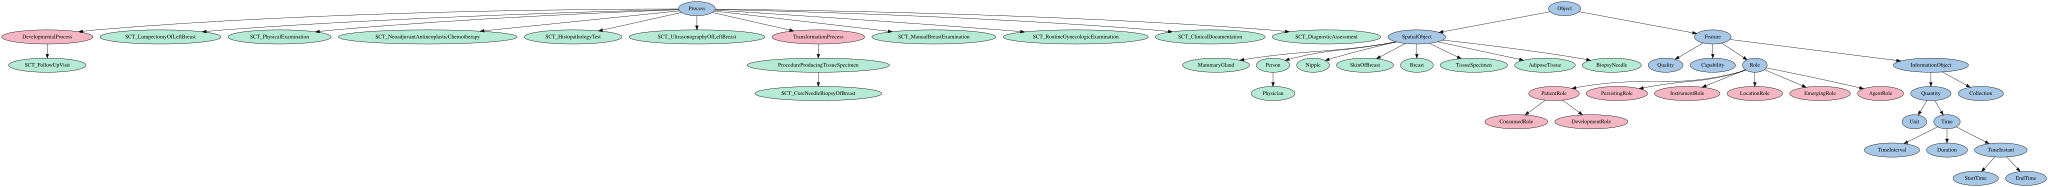

In [9]:
os.makedirs("dist", exist_ok=True)
mie.save(file="dist/mie-03.owl", format="rdfxml")
print("Saved dist/mie-03.owl")
print(f"  classes:                   {len(list(mie.classes()))}")
print(f"  individuals:               {len(list(mie.individuals()))}")
print(f"  object properties (local): {len(list(mie.object_properties()))}  ← still zero")
print(f"  imported ontologies:       {[o.base_iri for o in mie.imported_ontologies]}")

tree = get_color_tree([sulo, pro, mie])
display(tree)